# 🧑‍🤝‍🧑 Gender Detection dari Wajah — CNN + Kamera (Jupyter Notebook)

Notebook ini adalah project **GENDER_PREDICT**.

1. **Fitur utama:** cek muka pakai **kamera** langsung di komputer (tanpa upload) → sistem otomatis **deteksi wajah** → **prediksi gender (Pria/Wanita)** lengkap dengan skor keyakinan (confidence) dan visualisasi **Grad-CAM** (area wajah yang jadi fokus model).
2. **3 arsitektur model** dibandingkan: 2 CNN custom  + 1 model **Transfer Learning (MobileNetV2)** sebagai pembanding yang biasanya lebih akurat.
3. **Callback training** (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) supaya training lebih stabil & tidak overfitting.
4. **Evaluasi lengkap**: classification report, confusion matrix (heatmap), ROC curve, Precision-Recall curve, dan perbandingan akurasi 3 model (bar/line/pie).
5. **Pemilihan model terbaik otomatis** berdasarkan akurasi validasi, lalu disimpan.
6. **Prediksi batch** — taruh banyak foto di folder `foto_batch/`, hasil diringkas ke tabel & disimpan sebagai CSV.



## 1. Install & Import Library


In [1]:
# Cek dulu paket apa yang belum ada. Kalau semua sudah terpasang, cell ini langsung selesai (tidak install ulang).
# OpenCV dikunci ke 4.10.0.84 (versi 5.x tidak punya CascadeClassifier -> deteksi wajah error).
# Pakai "opencv-python" (bukan headless) supaya jendela kamera (cv2.imshow) bisa tampil.
import importlib.util
NEED = {"tensorflow": "tensorflow", "matplotlib": "matplotlib", "seaborn": "seaborn",
        "sklearn": "scikit-learn", "PIL": "pillow", "pandas": "pandas",
        "ipywidgets": "ipywidgets"}
missing = [pip for mod, pip in NEED.items() if importlib.util.find_spec(mod) is None]

cv_ok = False
if importlib.util.find_spec("cv2") is not None:
    try:
        import cv2
        cv_ok = hasattr(cv2, "CascadeClassifier")
    except Exception:
        cv_ok = False

if missing:
    print("Akan memasang:", missing, "(TensorFlow besar, bisa 5-30 menit; progress tampil di bawah, jangan diinterupsi)")
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
if not cv_ok:
    print("Memasang OpenCV 4.10.0.84 ...")
    get_ipython().run_line_magic("pip", "uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless")
    get_ipython().run_line_magic("pip", 'install "opencv-python==4.10.0.84"')

if missing or not cv_ok:
    print("\n✅ Selesai. Klik menu Kernel > Restart, lalu LEWATI cell ini dan lanjut dari cell berikutnya.")
else:
    print("✅ Semua paket sudah terpasang -> tidak perlu install. Lanjut.")

Akan memasang: ['ipywidgets'] (TensorFlow besar, bisa 5-30 menit; progress tampil di bawah, jangan diinterupsi)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 508.0 kB/s eta 0:00:04
   --------- ------------------------------ 0.5/2.2 MB 508.0 kB/s eta 0:00:04
   --------- ------------------------------ 0.5/2.2 MB 508.0 kB/s eta 0:00:04
   -------------- ------------------------- 0.8/2.2 MB 453.5 kB/s eta 0:00:04
   -------------- ------------------------- 0.8/2.2 MB 453.5 kB/s eta 0:00:04
   -------------- ------------------------- 0.8/2.2 MB 453.5 kB/s eta 0:0

In [7]:
import os
import io
import sys
import time
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_curve, auc, precision_recall_curve)

from PIL import Image
import IPython.display as ipd

# Versi lokal (Jupyter): tidak memakai google.colab / widget upload
IN_COLAB = False

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
OpenCV version: 4.13.0
GPU tersedia: []


## 2. Setup Dataset — Baca Langsung dari Komputer

In [9]:
# ============ UBAH SESUAI KOMPUTER KAMU ============
# Folder yang berisi Training/ & Validation/  ATAU  Training.zip & Validation.zip
# "." = folder yang sama dengan notebook ini.  Contoh Windows: r"C:\Users\nama\Downloads\dataset"
# Sebaiknya isi path yang SPESIFIK (jangan folder besar seperti C:\Users\nama), supaya tidak salah ambil folder.
SOURCE_DIR = "."
# ===================================================

KERAS_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".ppm", ".tif", ".tiff")      # format yang dibaca flow_from_directory
OTHER_IMG_EXTS = (".webp", ".jfif", ".gif", ".avif", ".heic")                # gambar, tapi TIDAK dibaca Keras
_SKIP_DIRS = {"appdata", "site-packages", "node_modules", "anaconda3", "miniconda3", "envs", "windows",
              "program files", "program files (x86)", "$recycle.bin", "__pycache__"}


def _count_images(folder):
    n_ok = n_other = 0
    for _, _, fs in os.walk(folder):
        for f in fs:
            e = os.path.splitext(f)[1].lower()
            if e in KERAS_EXTS:
                n_ok += 1
            elif e in OTHER_IMG_EXTS:
                n_other += 1
    return n_ok, n_other


def _class_counts(split_dir):
    """{nama_kelas: (gambar terbaca Keras, gambar format lain)} untuk tiap subfolder kelas."""
    return {d: _count_images(os.path.join(split_dir, d))
            for d in sorted(os.listdir(split_dir)) if os.path.isdir(os.path.join(split_dir, d))}


def find_dataset_pair(root, max_depth=6, verbose=True):
    """Cari pasangan Training/ + Validation/ (satu induk) yang BENAR-BENAR berisi gambar di >= 2 folder kelas.
    Kalau ada beberapa, dipilih yang gambar trainingnya paling banyak."""
    root = os.path.abspath(root)
    base = root.rstrip(os.sep).count(os.sep)
    found = []
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith(".") and d.lower() not in _SKIP_DIRS]
        if dirpath.count(os.sep) - base >= max_depth:
            dirnames[:] = []
        low = {d.lower(): d for d in dirnames}
        if "training" in low and "validation" in low:
            tr, va = os.path.join(dirpath, low["training"]), os.path.join(dirpath, low["validation"])
            tc, vc = _class_counts(tr), _class_counts(va)
            if sum(1 for n, _ in tc.values() if n > 0) >= 2 and sum(n for n, _ in vc.values()) > 0:
                found.append((sum(n for n, _ in tc.values()), tr, va))
    if not found:
        return None
    found.sort(reverse=True)
    if verbose:
        for n, tr, _ in found:
            print(f"  kandidat dataset: {tr}  ({n} gambar training)")
    return found[0][1], found[0][2]


def diagnose_dataset(root):
    """Tampilkan apa yang ada di folder bernama Training/Validation, supaya mudah ketahuan salahnya di mana."""
    print(f"Ringkasan pencarian di {os.path.abspath(root)}:")
    any_found = False
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith(".") and d.lower() not in _SKIP_DIRS]
        for d in dirnames:
            if d.lower() in ("training", "validation"):
                any_found = True
                pth = os.path.join(dirpath, d)
                print(" -", pth)
                cc = _class_counts(pth)
                if not cc:
                    print("     (tidak ada subfolder kelas: gambar harus ada di dalam subfolder, mis. female/ dan male/)")
                for c, (n, o) in cc.items():
                    extra = f", {o} file berformat lain (webp/jfif/gif) yang TIDAK dibaca Keras" if o else ""
                    print(f"     {c}: {n} gambar terbaca{extra}")
    if not any_found:
        print(" - tidak ada folder bernama Training / Validation sama sekali")


DATASET_ROOT = SOURCE_DIR
if find_dataset_pair(SOURCE_DIR, verbose=False):
    print("Dataset ditemukan di folder:", os.path.abspath(SOURCE_DIR))
else:
    zips = sorted(glob.glob(os.path.join(SOURCE_DIR, "*.zip")))
    if not zips:
        diagnose_dataset(SOURCE_DIR)
        raise FileNotFoundError(f"Dataset tidak ditemukan di {os.path.abspath(SOURCE_DIR)}. Isi SOURCE_DIR dengan folder yang berisi "
                                "Training/ & Validation/ (masing-masing punya subfolder kelas berisi gambar), atau Training.zip & Validation.zip.")
    DATASET_ROOT = "./dataset_gender"
    os.makedirs(DATASET_ROOT, exist_ok=True)
    for zip_name in zips:
        print(f"Mengekstrak {zip_name} ...")
        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall(DATASET_ROOT)      # file zip asli tidak dihapus

print("Isi folder dataset:")
for root, dirs, _ in os.walk(DATASET_ROOT):
    depth = root.replace(DATASET_ROOT, '').count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(os.path.normpath(root)) + "/")

Dataset ditemukan di folder: <SOURCE_DIR>
(Daftar isi folder dihapus dari versi GitHub karena berisi struktur folder pribadi.)


In [11]:
# (DATASET_ROOT sudah ditentukan di cell sebelumnya)
print("DATASET_ROOT =", os.path.abspath(DATASET_ROOT))

DATASET_ROOT = <SOURCE_DIR>


In [13]:
# Tentukan folder Training/ & Validation/ yang benar-benar berisi gambar (bukan sekadar folder bernama sama)
_pair = find_dataset_pair(DATASET_ROOT)
if _pair is None:
    diagnose_dataset(DATASET_ROOT)
    raise FileNotFoundError("Tidak ada pasangan folder Training/ + Validation/ yang berisi gambar (minimal 2 kelas, "
                            "mis. female/ & male/). Lihat ringkasan di atas, lalu perbaiki SOURCE_DIR / struktur foldernya.")
TRAIN_DIR, VAL_DIR = _pair

class_names_found = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("Path training  :", TRAIN_DIR)
print("Path validation:", VAL_DIR)
print("Kelas terdeteksi:", class_names_found)

for c in class_names_found:
    n_train = len(glob.glob(os.path.join(TRAIN_DIR, c, "*")))
    n_val = len(glob.glob(os.path.join(VAL_DIR, c, "*")))
    print(f"  - {c}: {n_train} gambar training, {n_val} gambar validation")


  kandidat dataset: ~\dataset_extracted\Training  (47009 gambar training)
  kandidat dataset: ~\dataset_48\Training  (47009 gambar training)
Path training  : ~\dataset_extracted\Training
Path validation: ~\dataset_extracted\Validation
Kelas terdeteksi: ['female', 'male']
  - female: 23243 gambar training, 5841 gambar validation
  - male: 23766 gambar training, 5808 gambar validation


## 3. Konfigurasi Umum

In [15]:
IMG_SIZE_GRAY = (48, 48)     # dipakai model1 & model2 (CNN custom, grayscale — sama seperti versi asli)
IMG_SIZE_RGB  = (96, 96)     # dipakai model3 (transfer learning MobileNetV2, butuh RGB)
BATCH_SIZE = 32
EPOCHS = 20

MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)


## 4. Data Generator & Augmentasi
Dua set generator disiapkan: versi **grayscale 48x48** (untuk model1 & model2, arsitektur CNN sederhana) dan versi **RGB 96x96** (untuk model3 transfer learning, karena MobileNetV2 butuh input RGB).

In [17]:
augment_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
plain_datagen = ImageDataGenerator(rescale=1./255)

# --- Generator grayscale (untuk model1 & model2) ---
train_gen_gray = augment_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_GRAY, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', seed=SEED)

val_gen_gray = plain_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_GRAY, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', shuffle=False)

# --- Generator RGB (untuk model3 transfer learning) ---
train_gen_rgb = augment_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_RGB, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='rgb', seed=SEED)

val_gen_rgb = plain_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_RGB, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='rgb', shuffle=False)

# Pengaman: berhenti di sini (dengan pesan jelas) kalau generator tidak menemukan gambar
for _nama, _gen in (("training", train_gen_gray), ("validation", val_gen_gray)):
    if _gen.samples == 0:
        raise ValueError(f"Generator {_nama} menemukan 0 gambar.\n  TRAIN_DIR = {TRAIN_DIR}\n  VAL_DIR   = {VAL_DIR}\n"
                         "Pastikan gambar ada di dalam subfolder kelas (Training/female/*.jpg, Training/male/*.jpg), "
                         "dan formatnya jpg/jpeg/png/bmp/tif (webp/jfif tidak dibaca).")

# Mapping index -> nama kelas (dipakai lagi di bagian prediksi)
CLASS_INDICES = train_gen_gray.class_indices          # contoh: {'Man': 0, 'Woman': 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}
print("Mapping kelas:", CLASS_INDICES)


Found 47009 images belonging to 2 classes.
Found 11649 images belonging to 2 classes.
Found 47009 images belonging to 2 classes.
Found 11649 images belonging to 2 classes.
Mapping kelas: {'female': 0, 'male': 1}


## 5. Cek Sebaran Data & Contoh Gambar

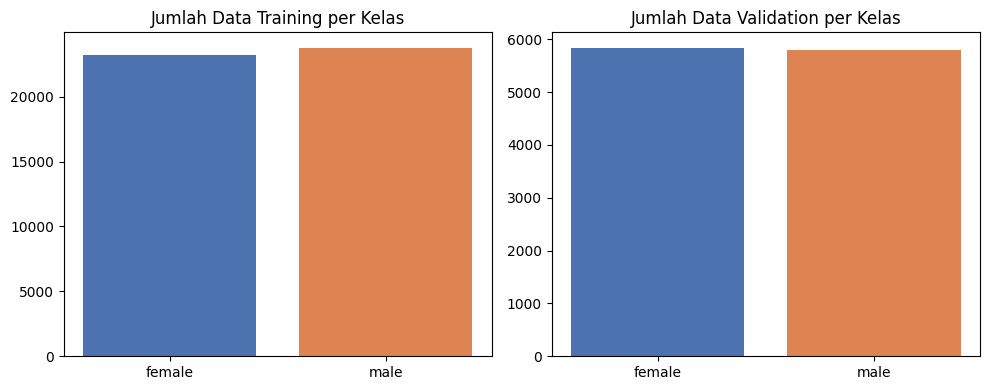

In [19]:
# Distribusi jumlah data per kelas
counts_train = [len(glob.glob(os.path.join(TRAIN_DIR, c, "*"))) for c in class_names_found]
counts_val = [len(glob.glob(os.path.join(VAL_DIR, c, "*"))) for c in class_names_found]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(class_names_found, counts_train, color=['#4C72B0', '#DD8452'])
ax[0].set_title("Jumlah Data Training per Kelas")
ax[1].bar(class_names_found, counts_val, color=['#4C72B0', '#DD8452'])
ax[1].set_title("Jumlah Data Validation per Kelas")
plt.tight_layout()
plt.show()


In [21]:
# Contoh batch gambar hasil augmentasi (grayscale)
sample_images, sample_labels = next(train_gen_gray)

plt.figure(figsize=(12, 6))
for i in range(min(10, len(sample_images))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    label = IDX_TO_CLASS[int(sample_labels[i])]
    plt.title(label)
    plt.axis('off')
plt.suptitle("Contoh Gambar Training Setelah Augmentasi")
plt.tight_layout()
plt.show()


(Gambar contoh augmentasi dihapus dari versi GitHub karena berisi foto wajah dari dataset pihak ketiga.)


### (Opsional) Lanjut dari model yang sudah tersimpan
Cell di bawah **hanya berguna di sesi berikutnya** (setelah Bagian 8 pernah selesai dan model ada di folder `models/`).
Di run pertama, cell ini otomatis dilewati dengan pesan — itu normal.

In [23]:
from tensorflow.keras.models import load_model

try:
    model1 = load_model(os.path.join(MODEL_DIR, "model1_best.h5"))
    model2 = load_model(os.path.join(MODEL_DIR, "model2_best.h5"))
    model3 = load_model(os.path.join(MODEL_DIR, "model3_best.h5"))
    BEST_MODEL = load_model(os.path.join(MODEL_DIR, "gender_model_best_overall.h5"))
    print("Model tersimpan berhasil dimuat dari", os.path.abspath(MODEL_DIR))
except (OSError, ValueError) as e:
    print("Belum ada model tersimpan di", os.path.abspath(MODEL_DIR), "-> normal di run pertama, lanjut ke bagian training.")

Belum ada model tersimpan di ~\models -> normal di run pertama, lanjut ke bagian training.


## 6. Arsitektur Model

- **Model 1**: CNN sederhana (persis arsitektur awal kamu) — 2 blok Conv-Pool.
- **Model 2**: CNN lebih dalam (persis arsitektur awal kamu) — 2 blok Conv-Pool dengan filter lebih banyak.
- **Model 3 (baru)**: Transfer Learning dengan **MobileNetV2** (pretrained ImageNet, base di-freeze lalu classifier head dilatih). Biasanya memberi akurasi lebih tinggi dan lebih tahan overfitting dibanding CNN dari nol, apalagi kalau data training tidak terlalu besar.


In [25]:
def build_model1():
    model = Sequential([
        L.InputLayer(input_shape=(48, 48, 1)),
        L.Conv2D(32, (3, 3), activation='relu'),
        L.MaxPooling2D((2, 2)),
        L.Conv2D(64, (3, 3), activation='relu'),
        L.MaxPooling2D((2, 2)),
        L.Flatten(),
        L.Dense(64, activation='relu'),
        L.Dropout(0.5),
        L.Dense(1, activation='sigmoid')
    ], name="model1_cnn_simple")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model2():
    model = Sequential([
        L.InputLayer(input_shape=(48, 48, 1)),
        L.Conv2D(64, (3, 3), activation='relu'),
        L.MaxPooling2D((2, 2)),
        L.Conv2D(128, (3, 3), activation='relu'),
        L.MaxPooling2D((2, 2)),
        L.Flatten(),
        L.Dense(128, activation='relu'),
        L.Dropout(0.5),
        L.Dense(1, activation='sigmoid')
    ], name="model2_cnn_deep")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model3_transfer():
    base_model = MobileNetV2(input_shape=(IMG_SIZE_RGB[0], IMG_SIZE_RGB[1], 3),
                              include_top=False, weights='imagenet')
    base_model.trainable = False  # freeze base, hanya latih classifier head

    inputs = L.Input(shape=(IMG_SIZE_RGB[0], IMG_SIZE_RGB[1], 3))
    x = base_model(inputs, training=False)
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.3)(x)
    x = L.Dense(64, activation='relu')(x)
    x = L.Dropout(0.3)(x)
    outputs = L.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="model3_mobilenetv2_transfer")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


model1 = build_model1()
model2 = build_model2()
model3 = build_model3_transfer()

model1.summary()


~\anaconda3\envs\cnn\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "model1_cnn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         409,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 428,545 (1.63 MB)

 Trainable params: 428,545 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
CLASS_INDICES = train_gen_gray.class_indices
IDX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}

BEST_MODEL_KEY = "model1"      # ganti sesuai model mana yang akurasinya tertinggi kemarin
BEST_COLOR_MODE = "grayscale"  # "grayscale" untuk model1/model2, "rgb" untuk model3
BEST_IMG_SIZE = IMG_SIZE_GRAY  # atau IMG_SIZE_RGB kalau model3 yang terbaik

## 7. Callback Training
Supaya training berhenti otomatis kalau sudah tidak membaik (`EarlyStopping`), learning rate diturunkan kalau stagnan (`ReduceLROnPlateau`), dan model terbaik selama training otomatis disimpan (`ModelCheckpoint`).

In [29]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(os.path.join(MODEL_DIR, f"{model_name}_best.h5"),
                         monitor='val_accuracy', save_best_only=True, verbose=0),
        CSVLogger(os.path.join(MODEL_DIR, f"{model_name}_log.csv"))
    ]


## 8. Training Ketiga Model
Bisa memakan waktu beberapa menit tergantung ukuran dataset & apakah runtime Colab pakai GPU (cek: Runtime → Change runtime type → GPU).

In [31]:
steps_per_epoch_gray = max(1, train_gen_gray.samples // train_gen_gray.batch_size)
val_steps_gray = max(1, val_gen_gray.samples // val_gen_gray.batch_size)

print(">> Training Model 1 (CNN sederhana)...")
history1 = model1.fit(
    train_gen_gray,
    steps_per_epoch=steps_per_epoch_gray,
    validation_data=val_gen_gray,
    validation_steps=val_steps_gray,
    epochs=EPOCHS,
    callbacks=get_callbacks("model1")
)


>> Training Model 1 (CNN sederhana)...


~\anaconda3\envs\cnn\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6201 - loss: 0.6427  

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 371s 251ms/step - accuracy: 0.6201 - loss: 0.6427 - val_accuracy: 0.8438 - val_loss: 0.3985 - learning_rate: 0.0010
Epoch 2/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 6:08 251ms/step - accuracy: 0.7812 - loss: 0.4701

~\anaconda3\envs\cnn\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9062 - loss: 0.2154 - val_accuracy: 0.9141 - val_loss: 0.2323 - learning_rate: 5.0000e-04
Epoch 11/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8753 - loss: 0.3088  

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 368s 250ms/step - accuracy: 0.8753 - loss: 0.3088 - val_accuracy: 0.9319 - val_loss: 0.1848 - learning_rate: 5.0000e-04
Epoch 12/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.8438 - loss: 0.3681 - val_accuracy: 0.9318 - val_loss: 0.1856 - learning_rate: 5.0000e-04
Epoch 13/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 367s 249ms/step - accuracy: 0.8831 - loss: 0.2946 - val_accuracy: 0.9264 - val_loss: 0.1960 - learning_rate: 5.0000e-04
Epoch 14/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 4:43 193ms/step - accuracy: 0.8750 - loss: 0.2911
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.8750 - loss: 0.2911 - val_accuracy: 0.9280 - val_loss: 0.1888 - learning_rate: 5.0000e-04
Epoch 15/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8916 - loss: 0.2783  

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 347s 236ms/step - accuracy: 0.8916 - loss: 0.2783 - val_accuracy: 0.9335 - val_loss: 0.1787 - learning_rate: 2.5000e-04
Epoch 16/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9688 - loss: 0.1603 - val_accuracy: 0.9334 - val_loss: 0.1790 - learning_rate: 2.5000e-04
Epoch 17/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 361s 245ms/step - accuracy: 0.8921 - loss: 0.2750 - val_accuracy: 0.9322 - val_loss: 0.1817 - learning_rate: 2.5000e-04
Epoch 18/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 6:17 257ms/step - accuracy: 1.0000 - loss: 0.1410
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 1.0000 - loss: 0.1410 - val_accuracy: 0.9322 - val_loss: 0.1828 - learning_rate: 2.5000e-04
Epoch 19/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8951 - loss: 0.2720  

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 347s 236ms/step - accuracy: 0.8951 - loss: 0.2720 - val_accuracy: 0.9369 - val_loss: 0.1670 - learning_rate: 1.2500e-04
Epoch 20/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 6:04 248ms/step - accuracy: 0.9375 - loss: 0.1120

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9375 - loss: 0.1120 - val_accuracy: 0.9371 - val_loss: 0.1671 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 20.


In [33]:
print(">> Training Model 2 (CNN lebih dalam)...")
history2 = model2.fit(
    train_gen_gray,
    steps_per_epoch=steps_per_epoch_gray,
    validation_data=val_gen_gray,
    validation_steps=val_steps_gray,
    epochs=EPOCHS,
    callbacks=get_callbacks("model2")
)


>> Training Model 2 (CNN lebih dalam)...
Epoch 1/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.6429 - loss: 0.6223   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 966s 656ms/step - accuracy: 0.6430 - loss: 0.6223 - val_accuracy: 0.8382 - val_loss: 0.3668 - learning_rate: 0.0010
Epoch 2/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.6562 - loss: 0.5549 - val_accuracy: 0.8315 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 3/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8132 - loss: 0.4273   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 954s 649ms/step - accuracy: 0.8132 - loss: 0.4273 - val_accuracy: 0.8759 - val_loss: 0.3017 - learning_rate: 0.0010
Epoch 4/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 13:23 548ms/step - accuracy: 0.8125 - loss: 0.3339

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - accuracy: 0.8125 - loss: 0.3339 - val_accuracy: 0.8824 - val_loss: 0.2896 - learning_rate: 0.0010
Epoch 5/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.8532 - loss: 0.3531   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 1346s 917ms/step - accuracy: 0.8532 - loss: 0.3531 - val_accuracy: 0.9078 - val_loss: 0.2350 - learning_rate: 0.0010
Epoch 6/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 16:02 656ms/step - accuracy: 0.9062 - loss: 0.2665

...

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 1019s 694ms/step - accuracy: 0.9070 - loss: 0.2406 - val_accuracy: 0.9436 - val_loss: 0.1546 - learning_rate: 5.0000e-04
Epoch 14/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 17:16 706ms/step - accuracy: 0.9062 - loss: 0.2445

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 73s 49ms/step - accuracy: 0.9062 - loss: 0.2445 - val_accuracy: 0.9438 - val_loss: 0.1547 - learning_rate: 5.0000e-04
Epoch 15/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 1017s 692ms/step - accuracy: 0.9079 - loss: 0.2386 - val_accuracy: 0.9429 - val_loss: 0.1537 - learning_rate: 5.0000e-04
Epoch 16/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 1.0000 - loss: 0.0757 - val_accuracy: 0.9427 - val_loss: 0.1556 - learning_rate: 5.0000e-04
Epoch 17/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.9125 - loss: 0.2301   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 1051s 716ms/step - accuracy: 0.9125 - loss: 0.2301 - val_accuracy: 0.9455 - val_loss: 0.1511 - learning_rate: 5.0000e-04
Epoch 18/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 85s 57ms/step - accuracy: 0.9062 - loss: 0.2259 - val_accuracy: 0.9454 - val_loss: 0.1516 - learning_rate: 5.0000e-04
Epoch 19/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9149 - loss: 0.2241   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 1067s 726ms/step - accuracy: 0.9149 - loss: 0.2241 - val_accuracy: 0.9457 - val_loss: 0.1520 - learning_rate: 5.0000e-04
Epoch 20/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 25:16 1s/step - accuracy: 1.0000 - loss: 0.1286
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


1469/1469 ━━━━━━━━━━━━━━━━━━━━ 87s 58ms/step - accuracy: 1.0000 - loss: 0.1286 - val_accuracy: 0.9462 - val_loss: 0.1518 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 20.


In [35]:
steps_per_epoch_rgb = max(1, train_gen_rgb.samples // train_gen_rgb.batch_size)
val_steps_rgb = max(1, val_gen_rgb.samples // val_gen_rgb.batch_size)

print(">> Training Model 3 (Transfer Learning MobileNetV2)...")
history3 = model3.fit(
    train_gen_rgb,
    steps_per_epoch=steps_per_epoch_rgb,
    validation_data=val_gen_rgb,
    validation_steps=val_steps_rgb,
    epochs=EPOCHS,
    callbacks=get_callbacks("model3")
)


>> Training Model 3 (Transfer Learning MobileNetV2)...
Epoch 1/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6972 - loss: 0.5948   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 892s 600ms/step - accuracy: 0.6972 - loss: 0.5948 - val_accuracy: 0.8174 - val_loss: 0.4009 - learning_rate: 1.0000e-04
Epoch 2/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 154s 104ms/step - accuracy: 0.5938 - loss: 0.9012 - val_accuracy: 0.8162 - val_loss: 0.4019 - learning_rate: 1.0000e-04
Epoch 3/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.7989 - loss: 0.4409   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 879s 598ms/step - accuracy: 0.7989 - loss: 0.4409 - val_accuracy: 0.8331 - val_loss: 0.3707 - learning_rate: 1.0000e-04
Epoch 4/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 18:52 771ms/step - accuracy: 0.7812 - loss: 0.4246

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 147s 100ms/step - accuracy: 0.7812 - loss: 0.4246 - val_accuracy: 0.8340 - val_loss: 0.3699 - learning_rate: 1.0000e-04
Epoch 5/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8091 - loss: 0.4203   

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 867s 590ms/step - accuracy: 0.8091 - loss: 0.4203 - val_accuracy: 0.8538 - val_loss: 0.3370 - learning_rate: 1.0000e-04
Epoch 6/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 145s 98ms/step - accuracy: 0.8438 - loss: 0.3778 - val_accuracy: 0.8531 - val_loss: 0.3382 - learning_rate: 1.0000e-04
Epoch 7/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 865s 589ms/step - accuracy: 0.8160 - loss: 0.4086 - val_accuracy: 0.8488 - val_loss: 0.3420 - learning_rate: 1.0000e-04
Epoch 8/20
   1/1469 ━━━━━━━━━━━━━━━━━━━━ 9:03 370ms/step - accuracy: 0.8438 - loss: 0.4350
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.8438 - loss: 0.4350 - val_accuracy: 0.8507 - val_loss: 0.3404 - learning_rate: 1.0000e-04
Epoch 9/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 886s 603ms/step - accuracy: 0.8214 - loss: 0.3983 - val_accuracy: 0.8498 - val_loss: 0.3436 - learning_rate: 5.0000e-05
Epoch 10/20
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 161

## 9. Grafik Proses Training

> ⚠️ **Catatan teknis tentang grafik training di bawah.** Kurva *akurasi dan loss **training*** tampak bergerigi karena `steps_per_epoch = samples // batch_size` (1469) tidak sama dengan jumlah batch generator (1470). Pada Keras 3, itu membuat sebagian epoch mencatat metrik **satu batch terakhir**, bukan rata-rata seluruh epoch (nilai seperti 0,7812 = 25/32 atau 1,0 = 32/32 adalah tandanya). Kurva **validasi** tampak normal, dan seluruh metrik di Bagian 10 dihitung terpisah pada semua data validasi, jadi tidak terpengaruh. Perbaikannya: hapus `steps_per_epoch` / `validation_steps` dari `fit()` (atau isi dengan `len(generator)`), lalu latih ulang.

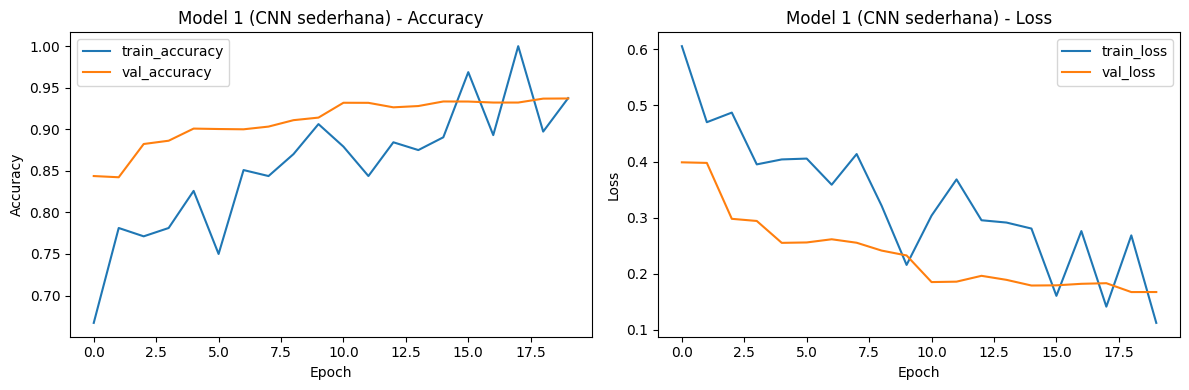

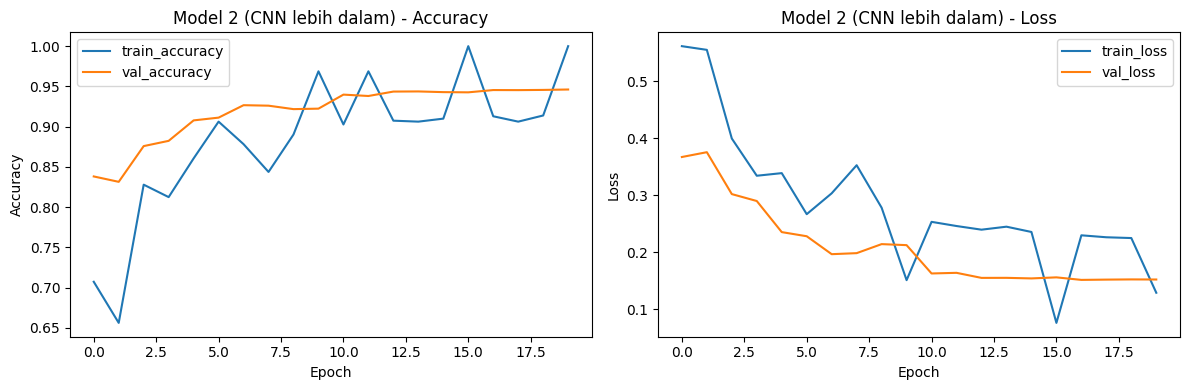

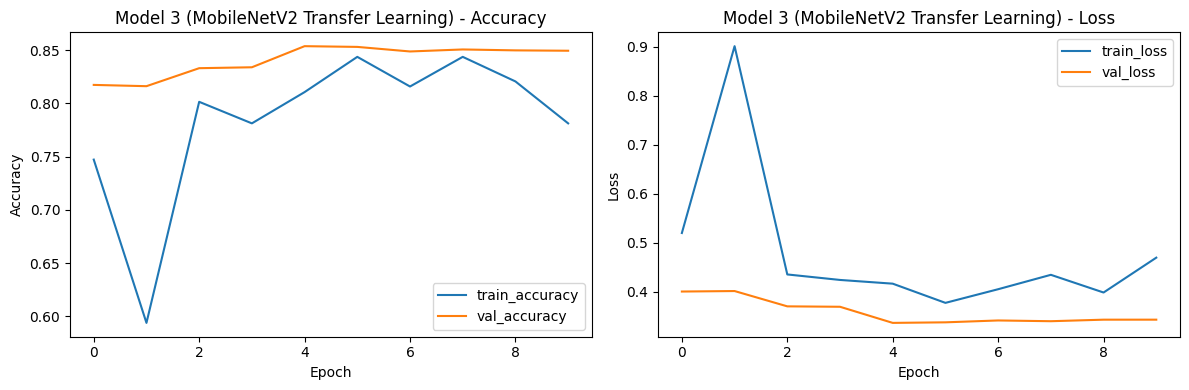

In [37]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['accuracy'], label='train_accuracy')
    ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
    ax[0].set_title(f'{title} - Accuracy')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Accuracy'); ax[0].legend()

    ax[1].plot(history.history['loss'], label='train_loss')
    ax[1].plot(history.history['val_loss'], label='val_loss')
    ax[1].set_title(f'{title} - Loss')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Loss'); ax[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, "Model 1 (CNN sederhana)")
plot_history(history2, "Model 2 (CNN lebih dalam)")
plot_history(history3, "Model 3 (MobileNetV2 Transfer Learning)")


## 10. Evaluasi & Perbandingan Model

Untuk tiap model dihitung: **classification report**, **confusion matrix**, **ROC curve (AUC)**, dan **Precision-Recall curve**, lalu akurasi ketiganya dibandingkan.

===== Model 1 (CNN sederhana) — Akurasi: 93.71% =====
              precision    recall  f1-score   support

      female       0.93      0.94      0.94      5841
        male       0.94      0.93      0.94      5808

    accuracy                           0.94     11649
   macro avg       0.94      0.94      0.94     11649
weighted avg       0.94      0.94      0.94     11649



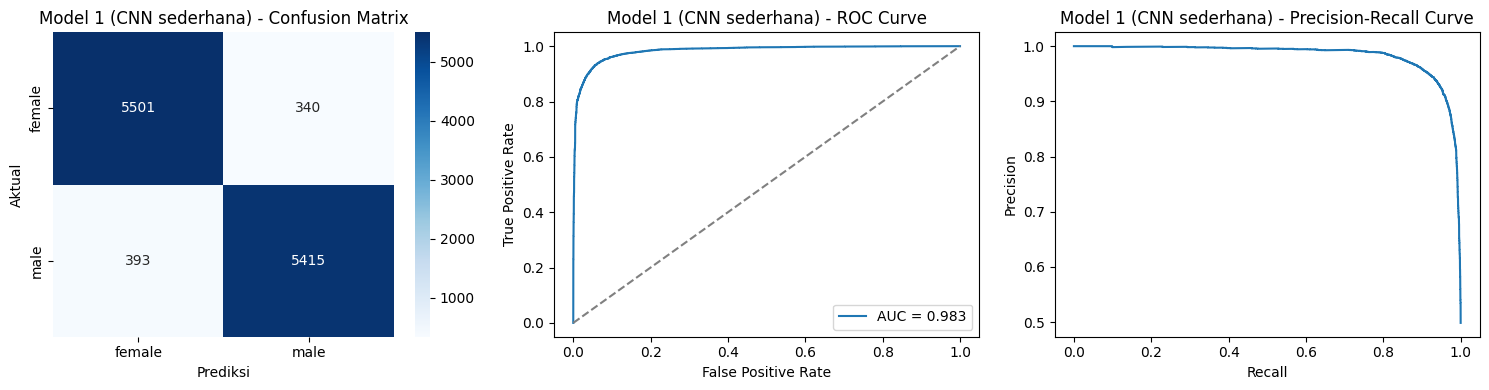

===== Model 2 (CNN lebih dalam) — Akurasi: 94.62% =====
              precision    recall  f1-score   support

      female       0.93      0.96      0.95      5841
        male       0.96      0.93      0.95      5808

    accuracy                           0.95     11649
   macro avg       0.95      0.95      0.95     11649
weighted avg       0.95      0.95      0.95     11649



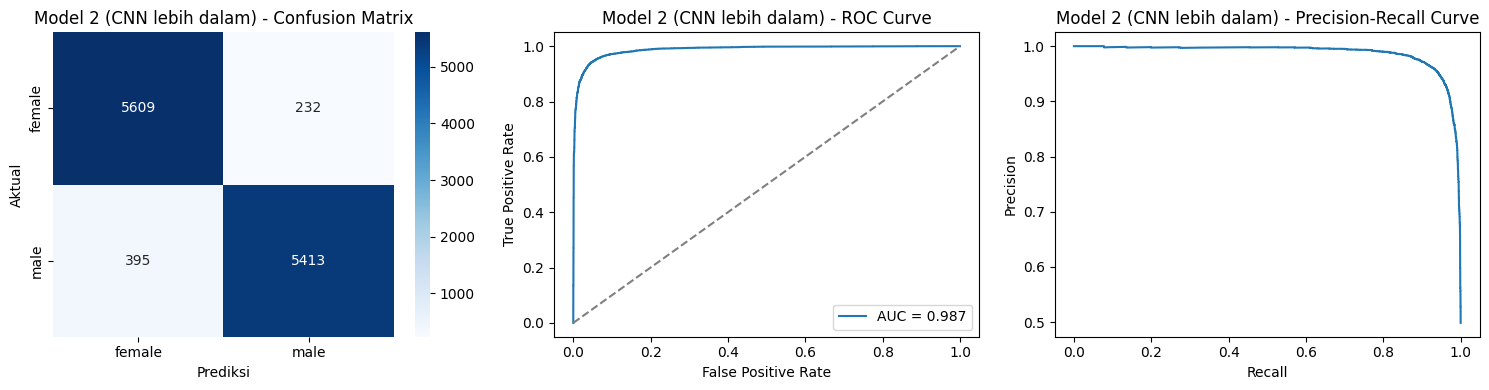

===== Model 3 (MobileNetV2) — Akurasi: 85.37% =====
              precision    recall  f1-score   support

      female       0.82      0.91      0.86      5841
        male       0.90      0.80      0.84      5808

    accuracy                           0.85     11649
   macro avg       0.86      0.85      0.85     11649
weighted avg       0.86      0.85      0.85     11649



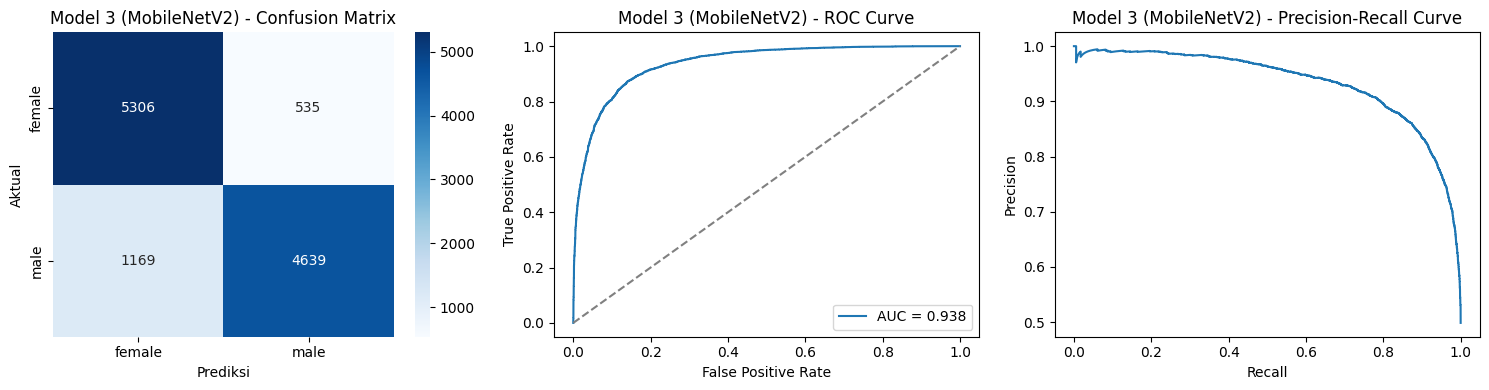

In [39]:
def evaluate_model(model, generator, model_name, class_labels):
    generator.reset()
    y_prob = model.predict(generator, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")
    y_true = generator.classes

    acc = accuracy_score(y_true, y_pred)
    print(f"===== {model_name} — Akurasi: {acc*100:.2f}% =====")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
                yticklabels=class_labels, ax=ax[0])
    ax[0].set_title(f'{model_name} - Confusion Matrix')
    ax[0].set_xlabel('Prediksi'); ax[0].set_ylabel('Aktual')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax[1].set_title(f'{model_name} - ROC Curve')
    ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate'); ax[1].legend()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ax[2].plot(recall, precision)
    ax[2].set_title(f'{model_name} - Precision-Recall Curve')
    ax[2].set_xlabel('Recall'); ax[2].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()
    return acc


class_labels_ordered = [IDX_TO_CLASS[0], IDX_TO_CLASS[1]]

acc_model1 = evaluate_model(model1, val_gen_gray, "Model 1 (CNN sederhana)", class_labels_ordered)
acc_model2 = evaluate_model(model2, val_gen_gray, "Model 2 (CNN lebih dalam)", class_labels_ordered)
acc_model3 = evaluate_model(model3, val_gen_rgb, "Model 3 (MobileNetV2)", class_labels_ordered)


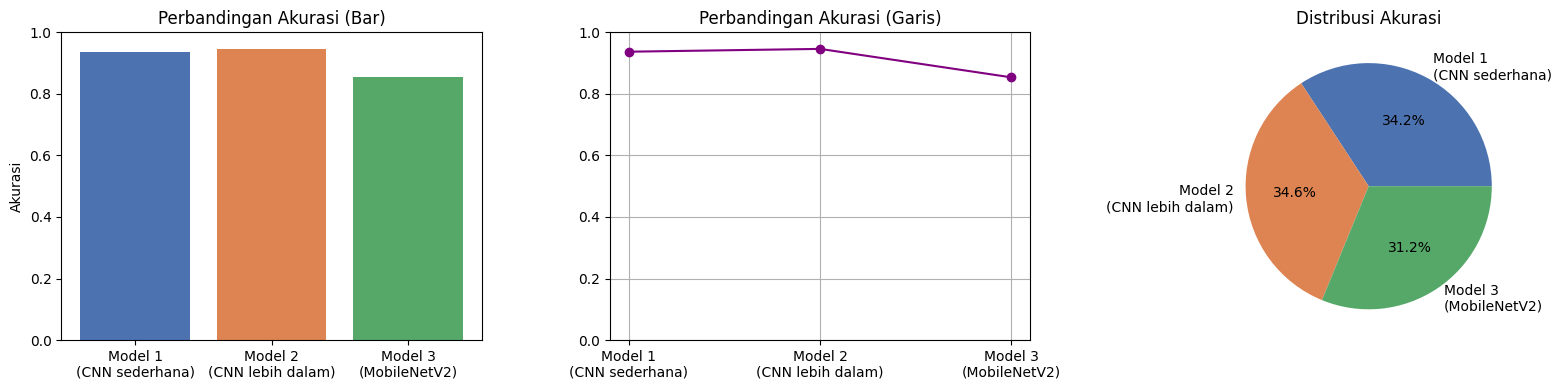

Model 1 (CNN sederhana): 93.71%
Model 2 (CNN lebih dalam): 94.62%
Model 3 (MobileNetV2): 85.37%


In [41]:
model_names = ['Model 1\n(CNN sederhana)', 'Model 2\n(CNN lebih dalam)', 'Model 3\n(MobileNetV2)']
accuracies = [acc_model1, acc_model2, acc_model3]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(model_names, accuracies, color=['#4C72B0', '#DD8452', '#55A868'])
ax[0].set_ylim(0, 1); ax[0].set_title('Perbandingan Akurasi (Bar)'); ax[0].set_ylabel('Akurasi')

ax[1].plot(model_names, accuracies, marker='o', color='purple')
ax[1].set_ylim(0, 1); ax[1].set_title('Perbandingan Akurasi (Garis)'); ax[1].grid(True)

ax[2].pie(accuracies, labels=model_names, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'])
ax[2].set_title('Distribusi Akurasi')

plt.tight_layout()
plt.show()

for name, acc in zip(model_names, accuracies):
    print(f"{name.splitlines()[0]} {name.splitlines()[1]}: {acc*100:.2f}%")


## 11. Pilih & Simpan Model Terbaik Otomatis
Model dengan akurasi validasi tertinggi dipakai sebagai model utama untuk semua fitur prediksi (upload foto, batch, webcam, Grad-CAM) di bagian selanjutnya.

In [43]:
models_info = {
    "model1": {"model": model1, "acc": acc_model1, "color_mode": "grayscale", "img_size": IMG_SIZE_GRAY},
    "model2": {"model": model2, "acc": acc_model2, "color_mode": "grayscale", "img_size": IMG_SIZE_GRAY},
    "model3": {"model": model3, "acc": acc_model3, "color_mode": "rgb", "img_size": IMG_SIZE_RGB},
}

BEST_MODEL_KEY = max(models_info, key=lambda k: models_info[k]["acc"])
BEST_MODEL = models_info[BEST_MODEL_KEY]["model"]
BEST_COLOR_MODE = models_info[BEST_MODEL_KEY]["color_mode"]
BEST_IMG_SIZE = models_info[BEST_MODEL_KEY]["img_size"]

best_model_path = os.path.join(MODEL_DIR, "gender_model_best_overall.h5")
BEST_MODEL.save(best_model_path)

# Simpan juga ketiganya biar bisa dibandingkan/dipakai manual kalau perlu
model1.save(os.path.join(MODEL_DIR, "gender_model1.h5"))
model2.save(os.path.join(MODEL_DIR, "gender_model2.h5"))
model3.save(os.path.join(MODEL_DIR, "gender_model3_mobilenetv2.h5"))

print(f"Model terbaik: {BEST_MODEL_KEY} dengan akurasi validasi {models_info[BEST_MODEL_KEY]['acc']*100:.2f}%")
print(f"Disimpan ke: {best_model_path}")
print(f"Semua model juga disimpan di folder: {MODEL_DIR}")


Model terbaik: model2 dengan akurasi validasi 94.62%
Disimpan ke: ./models\gender_model_best_overall.h5
Semua model juga disimpan di folder: ./models


## 12. Deteksi Wajah Otomatis

Sebelum foto dari kamera masuk ke model, sistem otomatis **mendeteksi & crop area wajah** (pakai Haar Cascade dari OpenCV) supaya prediksi lebih akurat dibanding memakai foto utuh (yang mungkin ada banyak background). Kalau tidak ada wajah terdeteksi, seluruh gambar dipakai sebagai fallback.

In [47]:
FACE_CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_crop_face(image_bgr, margin=0.25):
    """Deteksi wajah terbesar pada gambar (BGR/OpenCV format) lalu crop dengan sedikit margin.
    Mengembalikan (crop_bgr, bbox_or_None)."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = FACE_CASCADE.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    if len(faces) == 0:
        return image_bgr, None

    # ambil wajah dengan area terbesar (asumsi wajah utama/subjek foto)
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    mx, my = int(w * margin), int(h * margin)
    H, W = image_bgr.shape[:2]
    x0, y0 = max(0, x - mx), max(0, y - my)
    x1, y1 = min(W, x + w + mx), min(H, y + h + my)
    crop = image_bgr[y0:y1, x0:x1]
    return crop, (x0, y0, x1, y1)


## 13. Fungsi Prediksi Gender (Umum untuk Model Apapun)

In [49]:
def preprocess_for_model(crop_bgr, color_mode, img_size):
    """Ubah crop wajah (BGR) menjadi array siap masuk ke model, sesuai color_mode & ukuran model."""
    if color_mode == "grayscale":
        img = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, img_size)
        arr = img.astype("float32") / 255.0
        arr = np.expand_dims(arr, axis=-1)   # (H, W, 1)
    else:  # rgb
        img = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        arr = img.astype("float32") / 255.0  # (H, W, 3)
    return np.expand_dims(arr, axis=0)       # tambah dimensi batch -> (1, H, W, C)


def predict_gender(image_path, model=None, color_mode=None, img_size=None, use_face_detection=True):
    """Prediksi gender dari sebuah file gambar.
    Default memakai BEST_MODEL (model dengan akurasi validasi tertinggi).
    Mengembalikan dict berisi label, confidence, dan gambar-gambar perantara untuk divisualisasikan.
    """
    model = model or BEST_MODEL
    color_mode = color_mode or BEST_COLOR_MODE
    img_size = img_size or BEST_IMG_SIZE

    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise ValueError(f"Gagal membaca gambar: {image_path}")

    if use_face_detection:
        crop_bgr, bbox = detect_and_crop_face(image_bgr)
    else:
        crop_bgr, bbox = image_bgr, None

    input_arr = preprocess_for_model(crop_bgr, color_mode, img_size)
    prob = float(model.predict(input_arr, verbose=0).ravel()[0])

    pred_idx = 1 if prob > 0.5 else 0
    label = IDX_TO_CLASS[pred_idx]
    confidence = prob if pred_idx == 1 else 1 - prob

    return {
        "label": label,
        "confidence": confidence,
        "raw_score": prob,
        "original_bgr": image_bgr,
        "crop_bgr": crop_bgr,
        "bbox": bbox,
        "input_arr": input_arr,
    }


## 14. Grad-CAM — Visualisasi Area Wajah yang Jadi Fokus Model
Memberi "penjelasan" (explainability): bagian wajah mana yang paling memengaruhi keputusan model (mata, hidung, rahang, dll).

In [51]:
# Grad-CAM yang kompatibel dengan Keras 3 (TensorFlow 2.16+), termasuk model hasil load_model(...h5).
# Cara kerja: forward pass manual layer demi layer, lalu ambil feature map 4D terakhir (layer konvolusi terakhir;
# untuk model3 = keluaran seluruh sub-model MobileNetV2). Cara ini tidak memakai layer.output / output_shape
# yang bermasalah di Keras 3.

def _forward_collect(model, x):
    """Jalankan model layer demi layer. Mengembalikan (daftar (layer, output) berbentuk 4D, output akhir)."""
    feats = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x, training=False)
        if len(x.shape) == 4:
            feats.append((layer, x))
    return feats, x


def find_last_conv_layer(model):
    """Nama layer terakhir yang keluarannya berbentuk feature map 4D (H, W, C)."""
    shape = [1] + [int(d) for d in model.inputs[0].shape[1:]]
    feats, _ = _forward_collect(model, tf.zeros(shape, dtype=tf.float32))
    if not feats:
        raise ValueError("Tidak menemukan layer konvolusional untuk Grad-CAM.")
    return feats[-1][0].name


def make_gradcam_heatmap(input_arr, model, last_conv_layer_name=None):
    x = tf.convert_to_tensor(input_arr, dtype=tf.float32)
    with tf.GradientTape() as tape:
        feats, preds = _forward_collect(model, x)
        if last_conv_layer_name is None:
            conv_outputs = feats[-1][1]
        else:
            conv_outputs = next(o for l, o in feats if l.name == last_conv_layer_name)

        # Skor kelas yang DIPREDIKSI, dalam bentuk logit supaya gradien tidak "mati" saat sigmoid jenuh (~0 atau ~1)
        p = tf.clip_by_value(preds[:, 0], 1e-6, 1 - 1e-6)
        logit = tf.math.log(p) - tf.math.log(1 - p)
        score = logit if float(p[0]) > 0.5 else -logit

    grads = tape.gradient(score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_outputs[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0)
    if float(tf.reduce_max(heatmap)) <= 0:          # semua negatif -> pakai besar nilainya saja
        heatmap = tf.abs(tf.squeeze(conv_outputs[0] @ pooled_grads[..., tf.newaxis]))
    peak = tf.math.reduce_max(heatmap)
    if float(peak) > 0:
        heatmap = heatmap / peak                    # normalisasi 0..1 (tanpa epsilon, tahan nilai gradien yang sangat kecil)
    return heatmap.numpy()


def overlay_gradcam(crop_bgr, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (crop_bgr.shape[1], crop_bgr.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(crop_bgr, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

In [53]:
import pandas as pd

def get_best_val_acc(log_path):
    df = pd.read_csv(log_path)
    return df["val_accuracy"].max()

acc_model1 = get_best_val_acc(os.path.join(MODEL_DIR, "model1_log.csv"))
acc_model2 = get_best_val_acc(os.path.join(MODEL_DIR, "model2_log.csv"))
acc_model3 = get_best_val_acc(os.path.join(MODEL_DIR, "model3_log.csv"))

models_info = {
    "model1": {"model": model1, "acc": acc_model1, "color_mode": "grayscale", "img_size": IMG_SIZE_GRAY},
    "model2": {"model": model2, "acc": acc_model2, "color_mode": "grayscale", "img_size": IMG_SIZE_GRAY},
    "model3": {"model": model3, "acc": acc_model3, "color_mode": "rgb", "img_size": IMG_SIZE_RGB},
}

BEST_MODEL_KEY = max(models_info, key=lambda k: models_info[k]["acc"])
BEST_MODEL = models_info[BEST_MODEL_KEY]["model"]
BEST_COLOR_MODE = models_info[BEST_MODEL_KEY]["color_mode"]
BEST_IMG_SIZE = models_info[BEST_MODEL_KEY]["img_size"]

print("Akurasi validasi terbaik tiap model:")
print(f"  model1: {acc_model1*100:.2f}%")
print(f"  model2: {acc_model2*100:.2f}%")
print(f"  model3: {acc_model3*100:.2f}%")
print(f"\nModel terbaik dipilih: {BEST_MODEL_KEY}")

Akurasi validasi terbaik tiap model:
  model1: 93.71%
  model2: 94.62%
  model3: 85.38%

Model terbaik dipilih: model2


## 15. 🎯 FITUR UTAMA — Cek Muka: Upload Foto atau Kamera

Ada dua cara, pilih salah satu (atau dua-duanya):

**A. Tombol upload foto** — jalankan cell "Upload foto", klik **Pilih foto**, pilih satu atau beberapa foto dari komputer, lalu klik **Prediksi**. Ini upload dari browser ke komputer kamu sendiri (bukan ke Colab), jadi cepat dan tidak putus.

**B. Kamera** — jalankan cell terakhir di bagian ini:
- **mode "window"** (default): jendela kamera terbuka → **klik jendelanya dulu** → **SPASI** = ambil foto, **ESC** = batal.
- **mode "countdown"**: tanpa jendela, hitung mundur lalu foto otomatis (pakai ini kalau jendela macet / tidak muncul).

Sistem akan mendeteksi wajah, memprediksi gender (Pria/Wanita) beserta persentase keyakinan, lalu menampilkan foto, crop wajah, dan **Grad-CAM heatmap**.

> Bisa dijalankan berkali-kali tanpa training ulang. Kalau kamera tidak terbuka: coba `take_photo_local(cam_index=1)`, tutup aplikasi lain yang memakai kamera, dan cek izin kamera.

In [55]:
def show_prediction_result(image_path):
    result = predict_gender(image_path)

    fig, ax = plt.subplots(1, 3, figsize=(13, 4))

    ax[0].imshow(cv2.cvtColor(result["original_bgr"], cv2.COLOR_BGR2RGB))
    ax[0].set_title("Foto Asli")
    ax[0].axis('off')
    if result["bbox"] is not None:
        x0, y0, x1, y1 = result["bbox"]
        rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='lime', facecolor='none', linewidth=2)
        ax[0].add_patch(rect)

    ax[1].imshow(cv2.cvtColor(result["crop_bgr"], cv2.COLOR_BGR2RGB))
    ax[1].set_title("Wajah Terdeteksi (Crop)")
    ax[1].axis('off')

    try:
        heatmap = make_gradcam_heatmap(result["input_arr"], BEST_MODEL)
        overlay = overlay_gradcam(cv2.resize(result["crop_bgr"], (200, 200)),
                                   heatmap)
        ax[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax[2].set_title("Grad-CAM (Fokus Model)")
    except Exception as e:
        print(f"(Grad-CAM gagal: {type(e).__name__}: {e})")
        ax[2].text(0.5, 0.5, "Grad-CAM tidak tersedia\nuntuk model ini", ha='center', va='center')
        ax[2].set_title("Grad-CAM")
    ax[2].axis('off')

    label_id = result["label"]
    conf_pct = result["confidence"] * 100
    fig.suptitle(f"Prediksi: {label_id}  (Keyakinan: {conf_pct:.1f}%)   |   Model: {BEST_MODEL_KEY}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"📌 Hasil  : {label_id}")
    print(f"📊 Keyakinan: {conf_pct:.2f}%")
    print(f"🧠 Model dipakai: {BEST_MODEL_KEY} (akurasi validasi {models_info[BEST_MODEL_KEY]['acc']*100:.2f}%)")
    return result

In [57]:
# ▶️ Upload foto lewat tombol (ipywidgets). Bisa pilih banyak foto sekaligus.
import ipywidgets as widgets
from IPython.display import display

UPLOAD_DIR = "foto_upload"          # foto yang dipilih disimpan di folder ini
os.makedirs(UPLOAD_DIR, exist_ok=True)

uploader = widgets.FileUpload(accept="image/*", multiple=True, description="Pilih foto")
btn_predict = widgets.Button(description="Prediksi", button_style="success", icon="search")
out_upload = widgets.Output()


def _iter_uploaded(up):
    """Kompatibel ipywidgets 7 (dict) dan 8 (tuple)."""
    v = up.value
    if isinstance(v, dict):
        for name, meta in v.items():
            yield name, bytes(meta["content"])
    else:
        for item in v:
            yield item["name"], bytes(item["content"])


def _on_predict_click(_):
    with out_upload:
        out_upload.clear_output()
        items = list(_iter_uploaded(uploader))
        if not items:
            print("Pilih foto dulu lewat tombol 'Pilih foto', lalu klik 'Prediksi'.")
            return
        for name, data in items:
            path = os.path.join(UPLOAD_DIR, os.path.basename(name))
            with open(path, "wb") as f:
                f.write(data)
            print("\n" + "=" * 60)
            print(f"Foto: {name}")
            try:
                show_prediction_result(path)
            except Exception as e:
                print(f"Gagal memproses {name}: {type(e).__name__}: {e}")


btn_predict.on_click(_on_predict_click)
display(widgets.HBox([uploader, btn_predict]))
display(out_upload)

(Widget interaktif: hanya tampil saat notebook dijalankan di Jupyter.)


In [ ]:
def take_photo_local(cam_index=0, mode="window", countdown=5):
    """
    mode="window"    : jendela kamera terbuka (klik jendelanya dulu), SPASI = ambil foto, ESC = batal.
    mode="countdown" : tanpa jendela, hitung mundur lalu foto otomatis (pakai ini kalau jendela macet/tidak muncul).
    Mengembalikan frame BGR, atau None kalau dibatalkan.
    """
    backend = cv2.CAP_DSHOW if sys.platform.startswith("win") else cv2.CAP_ANY
    cap = cv2.VideoCapture(cam_index, backend)

    if not cap.isOpened():
        raise RuntimeError(
            f"Kamera index {cam_index} tidak bisa dibuka. "
            "Coba cam_index=1, tutup aplikasi lain yang memakai kamera, "
            "dan cek izin kamera (Windows: Settings > Privacy > Camera; "
            "macOS: izinkan Terminal/Anaconda)."
        )

    frame = None

    try:
        # Warm-up supaya exposure stabil
        for _ in range(10):
            cap.read()

        if mode == "window":
            try:
                print(
                    "Jendela kamera terbuka. "
                    "KLIK jendelanya dulu, lalu SPASI = ambil foto, ESC = batal."
                )

                while True:
                    ok, f = cap.read()

                    if not ok:
                        raise RuntimeError(
                            "Gagal membaca frame dari kamera."
                        )

                    view = f.copy()

                    cv2.putText(
                        view,
                        "SPASI = ambil foto | ESC = batal",
                        (10, 28),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (0, 255, 0),
                        2
                    )

                    cv2.imshow("Kamera", view)

                    k = cv2.waitKey(1) & 0xFF

                    # Tombol SPASI
                    if k == 32:
                        frame = f
                        break

                    # Tombol ESC
                    if k == 27:
                        break

            except cv2.error:
                print(
                    "Jendela tidak tersedia di OpenCV ini "
                    "-> beralih ke mode countdown."
                )
                mode = "countdown"

        if mode == "countdown":
            print("Mode countdown dimulai...")

            for i in range(countdown, 0, -1):
                print(f"Foto dalam {i}...", end="\r", flush=True)
                time.sleep(1)

            # Ambil beberapa frame agar mendapatkan frame terbaru
            for _ in range(5):
                ok, f = cap.read()

            frame = f if ok else None

            print("\nFoto diambil.")

    finally:
        cap.release()

        try:
            cv2.destroyAllWindows()

            for _ in range(5):
                cv2.waitKey(1)

        except cv2.error:
            pass

    return frame


# ▶️ Jalankan cell ini setiap kali mau cek muka
frame = take_photo_local()

# Kalau jendela kamera macet/tidak muncul, gunakan:
# frame = take_photo_local(mode="countdown")

if frame is None:
    print("Dibatalkan / tidak ada foto.")

else:
    cv2.imwrite("webcam_photo.jpg", frame)
    show_prediction_result("webcam_photo.jpg")

## 16. Prediksi Banyak Foto Sekaligus (Batch) + Export CSV

Taruh foto-foto di folder **`foto_batch/`** (sebelah notebook ini), lalu jalankan cell di bawah. Hasilnya diringkas ke tabel dan disimpan sebagai `hasil_prediksi_gender.csv`. Kalau folder tidak ada / kosong, cell ini dilewati.

In [67]:
def batch_predict(image_paths):
    rows = []
    for path in image_paths:
        try:
            r = predict_gender(path)
            rows.append({
                "file_name": os.path.basename(path),
                "prediksi": r["label"],
                "keyakinan (%)": round(r["confidence"] * 100, 2),
                "wajah_terdeteksi": r["bbox"] is not None
            })
        except Exception as e:
            rows.append({"file_name": os.path.basename(path), "prediksi": "ERROR",
                         "keyakinan (%)": None, "wajah_terdeteksi": False})
            print(f"Gagal memproses {path}: {e}")
    return pd.DataFrame(rows)



BATCH_DIR = "foto_batch"      # folder berisi foto-foto yang mau diprediksi
_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
batch_paths = sorted(p for p in glob.glob(os.path.join(BATCH_DIR, "*")) if p.lower().endswith(_exts)) if os.path.isdir(BATCH_DIR) else []

if batch_paths:
    df_result = batch_predict(batch_paths)
    display(df_result)

    csv_path = "hasil_prediksi_gender.csv"
    df_result.to_csv(csv_path, index=False)
    print(f"\nHasil disimpan ke {os.path.abspath(csv_path)}")
else:
    print(f"Folder '{BATCH_DIR}/' tidak ada atau kosong -> prediksi batch dilewati.")

(Tabel hasil prediksi batch dihapus dari versi GitHub karena berisi nama file foto pribadi.)


## 17. Ringkasan Fitur di Notebook Ini

| Fitur | Keterangan |
|---|---|
| ✅ Cek muka: tombol upload foto & kamera + deteksi gender | Bagian 15 — fitur utama (upload via tombol, atau jendela kamera / countdown) |
| ✅ Deteksi wajah otomatis | Bagian 12, pakai OpenCV Haar Cascade |
| ✅ Grad-CAM (explainability) | Bagian 14–15, menunjukkan fokus model |
| ✅ Prediksi batch banyak foto (dari folder) + CSV | Bagian 16 |
| ✅ 3 model dibandingkan (2 CNN + transfer learning) | Bagian 6, 8 |
| ✅ Callback training (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) | Bagian 7 |
| ✅ Evaluasi lengkap (report, confusion matrix, ROC, PR curve) | Bagian 10 |
| ✅ Pemilihan & penyimpanan model terbaik otomatis | Bagian 11 |


**Tips lanjutan:**
- Kalau akurasi masih kurang memuaskan, coba tambah data training, atau fine-tune sebagian layer MobileNetV2 (`base_model.trainable = True` untuk beberapa layer terakhir) dengan learning rate kecil.
- Model grayscale 48×48 dari arsitektur CNN sederhana cukup ringan & cepat, cocok untuk deploy di perangkat terbatas; model MobileNetV2 lebih akurat tapi filenya lebih besar.
